## Project Summary

This project means to develop a Machine Learning Model which can classify a transaction as fraudulant or genuine.
The dataset user for training purpose is [Fraudulent Transactions Data](https://www.kaggle.com/datasets/chitwanmanchanda/fraudulent-transactions-data) and the model trained is XGBoost (eXtreme Gradient Boosting).

XGBoost is used to build the predictive engine for this project. As an ensemble learning method, it sequentially constructs decision trees where each new learner is optimized to correct the residuals (errors) of its predecessors. This "Extreme" version of gradient boosting was chosen for its exceptional speed, sparsity-aware split finding, and robust performance in competitive data science environments.

## Data Preprocessing

In [97]:
import numpy as np
import pandas as pd

In [98]:
df = pd.read_csv('Fraud.csv')

In [99]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


### Data Exploration

Note: Step is unit of time (equivalent to 1 hour). Total 743 hour means 30 days of time period.

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [101]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [102]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [103]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

### Dropping Duplicates

In [104]:
df.drop_duplicates(inplace=True)
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [105]:
df.sort_values('step').reset_index(drop=True)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,TRANSFER,26923.42,C1108517064,11049.67,0.00,C1983747920,199404.91,95508.95,0,0
1,1,PAYMENT,2803.83,C1129433283,0.00,0.00,M864138492,0.00,0.00,0,0
2,1,PAYMENT,106.81,C1810518740,0.00,0.00,M295180183,0.00,0.00,0,0
3,1,PAYMENT,6297.71,C1547883191,762.00,0.00,M1650113431,0.00,0.00,0,0
4,1,PAYMENT,2610.01,C1528769018,58697.54,56087.54,M183155105,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362616,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.00,C1470998563,0.00,0.00,1,0


Making Sure that the minimum balance is non-negative. 

In [106]:
cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
for col in cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

In [107]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Dropping isFlaggedFraud feature

In [108]:
df.drop(['isFlaggedFraud'], axis=1, inplace=True)

In [109]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


## Feature Engineering

Here, the original features (step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig, nameDest,	oldbalanceDest,	newbalanceDest,	isFraud,isFlaggedFraud) is transformed to new features(step	type, amount, nameOrig,	oldbalanceOrg, newbalanceOrig, nameDest, oldbalanceDest, newbalanceDest,isFraud, prev_step_user, recency_hours,	txn_count_24hr,	user_dest_count, is_dest_new, hours_of_day, type_CASH_IN, type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER)

Calculating the difference between transactions' time.

In [110]:
df['prev_step_user'] = df.groupby("nameOrig")["step"].shift(1)      #Groups the user and shifts the last transaction time 1 row below into prev_Step_user.
df['recency_hours'] = (df['step'] - df['prev_step_user']).fillna(1e6)


In [111]:
df[5000:]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,prev_step_user,recency_hours
5000,5,CASH_IN,10870.95,C1124131392,4926346.82,4937217.76,C769507769,84466.10,73595.15,0,NaN,1000000.0
5001,5,CASH_IN,44694.86,C1598068850,4937217.76,4981912.63,C1459035867,58638.78,13943.92,0,NaN,1000000.0
5002,5,CASH_IN,208812.28,C1417325106,4981912.63,5190724.91,C801142660,1482025.15,1273212.87,0,NaN,1000000.0
5003,5,CASH_IN,146193.70,C1194106760,5190724.91,5336918.60,C146305349,344441.76,198248.07,0,NaN,1000000.0
5004,5,CASH_IN,201261.11,C58353615,5336918.60,5538179.71,C564160838,217964.09,16702.98,0,NaN,1000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,NaN,1000000.0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,NaN,1000000.0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,NaN,1000000.0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,NaN,1000000.0


prev_step_user is mostly NaN value because there is 6362620 transactions and 6353307 nameOrig so very few groups are formed and most user have done only one transaction.

In [112]:
df['txn_count_24hr'] = df.groupby('nameOrig')['step'].diff().lt(24).groupby(df['nameOrig']).cumsum().fillna(0)
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,prev_step_user,recency_hours,txn_count_24hr
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,NaN,1000000.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,NaN,1000000.0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,NaN,1000000.0,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,NaN,1000000.0,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,NaN,1000000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,NaN,1000000.0,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,NaN,1000000.0,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,NaN,1000000.0,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,NaN,1000000.0,0


Checking if the destination account is new.

In [113]:
df['user_dest_count'] = df.groupby(['nameOrig', 'nameDest']).cumcount()
df['is_dest_new'] = (df['user_dest_count']==0).astype(int)
df.drop(columns=['user_dest_count'])
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,prev_step_user,recency_hours,txn_count_24hr,user_dest_count,is_dest_new
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,NaN,1000000.0,0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,NaN,1000000.0,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,NaN,1000000.0,0,0,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,NaN,1000000.0,0,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,NaN,1000000.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,NaN,1000000.0,0,0,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,NaN,1000000.0,0,0,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,NaN,1000000.0,0,0,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,NaN,1000000.0,0,0,1


Calculating the time of transaction. Useful to detect txn at unusual time.

In [114]:
df['hours_of_day']  = df['step']%24
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,prev_step_user,recency_hours,txn_count_24hr,user_dest_count,is_dest_new,hours_of_day
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,NaN,1000000.0,0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,NaN,1000000.0,0,0,1,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,NaN,1000000.0,0,0,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,NaN,1000000.0,0,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,NaN,1000000.0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,NaN,1000000.0,0,0,1,23
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,NaN,1000000.0,0,0,1,23
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,NaN,1000000.0,0,0,1,23
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,NaN,1000000.0,0,0,1,23


Converting Categorical Data into Binary.

In [115]:
dummies = pd.get_dummies(df['type'], prefix='type')
df = pd.concat([df, dummies], axis=1)
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,recency_hours,txn_count_24hr,user_dest_count,is_dest_new,hours_of_day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,...,1000000.0,0,0,1,1,False,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,...,1000000.0,0,0,1,1,False,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,...,1000000.0,0,0,1,1,False,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,...,1000000.0,0,0,1,1,False,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,...,1000000.0,0,0,1,1,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,...,1000000.0,0,0,1,23,False,True,False,False,False
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,...,1000000.0,0,0,1,23,False,False,False,False,True
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,...,1000000.0,0,0,1,23,False,True,False,False,False
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,...,1000000.0,0,0,1,23,False,False,False,False,True


Filtering Relevant Features

In [116]:
X = df[["amount", "recency_hours", "txn_count_24hr", "is_dest_new", "hours_of_day", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "type_CASH_IN", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT", "type_TRANSFER"]]

target = df["isFraud"]

In [117]:
X

,amount,recency_hours,txn_count_24hr,is_dest_new,hours_of_day,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,1000000.0,0,1,1,170136.00,160296.36,0.00,0.00,False,False,False,True,False
1,1864.28,1000000.0,0,1,1,21249.00,19384.72,0.00,0.00,False,False,False,True,False
2,181.00,1000000.0,0,1,1,181.00,0.00,0.00,0.00,False,False,False,False,True
3,181.00,1000000.0,0,1,1,181.00,0.00,21182.00,0.00,False,True,False,False,False
4,11668.14,1000000.0,0,1,1,41554.00,29885.86,0.00,0.00,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1000000.0,0,1,23,339682.13,0.00,0.00,339682.13,False,True,False,False,False
6362616,6311409.28,1000000.0,0,1,23,6311409.28,0.00,0.00,0.00,False,False,False,False,True
6362617,6311409.28,1000000.0,0,1,23,6311409.28,0.00,68488.84,6379898.11,False,True,False,False,False
6362618,850002.52,1000000.0,0,1,23,850002.52,0.00,0.00,0.00,False,False,False,False,True


In [118]:
target

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

## Final Data Summary

In [119]:
print("Training Set Class Counts:")
print(target.value_counts())

Training Set Class Counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


C:\Users\HIMANSHU\AppData\Local\Temp\ipykernel_10140\1559715283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette='viridis')


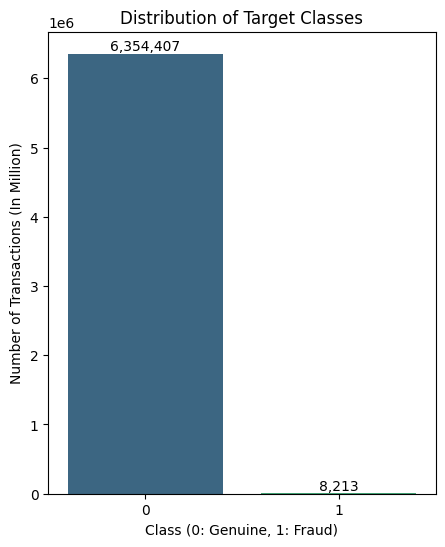

In [146]:
import seaborn as sns

counts = target.value_counts()

plt.figure(figsize=(5, 6))
ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette='viridis')

plt.title('Distribution of Target Classes')
plt.xlabel('Class (0: Genuine, 1: Fraud)')
plt.ylabel('Number of Transactions (In Million)')

# Add exact count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

## Data Split

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, target, test_size = 0.2, random_state=42, stratify=target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42, stratify=y_temp)

print(f"Training Set : {len(X_train)} rows")
print(f"Validation Set : {len(X_val)} rows")
print(f"Test Set : {len(X_test)} rows")

Training Set : 5090096 rows
Validation Set : 636262 rows
Test Set : 636262 rows


## Model Training

In [121]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators = 150, max_depth = 8, learning_rate = 0.15, scale_pos_weight=120, random_state=42)

model.fit(X_train, y_train, eval_set = [(X_val, y_val)], verbose=10)

[0]	validation_0-logloss:0.17954
[10]	validation_0-logloss:0.04524
[20]	validation_0-logloss:0.01610
[30]	validation_0-logloss:0.00892
[40]	validation_0-logloss:0.00682
[50]	validation_0-logloss:0.00580
[60]	validation_0-logloss:0.00494
[70]	validation_0-logloss:0.00431
[80]	validation_0-logloss:0.00376
[90]	validation_0-logloss:0.00342
[100]	validation_0-logloss:0.00318
[110]	validation_0-logloss:0.00289
[120]	validation_0-logloss:0.00272
[130]	validation_0-logloss:0.00256
[140]	validation_0-logloss:0.00246
[149]	validation_0-logloss:0.00233


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Metrics

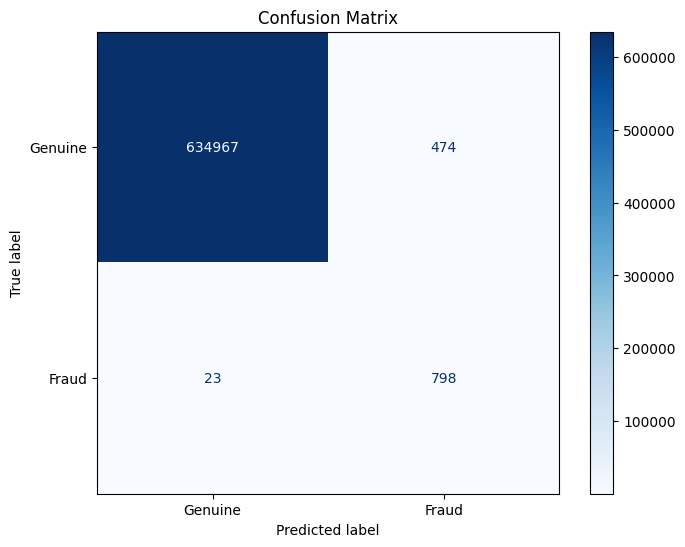

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create the display object, specifying the labels for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' formats the numbers as integers

plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, f1_score

probabilities = model.predict_proba(X_test)[:, 1]
y_pred = (probabilities > 0.55).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
auc_score = roc_auc_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall : {rec:.4f}")
print(f"F1 : {f1:.4f}")
print(f"AUC : {auc_score:.4f}")

Accuracy : 0.9992
Precision : 0.6274
Recall : 0.9720
F1 : 0.8811
AUC : 0.9856


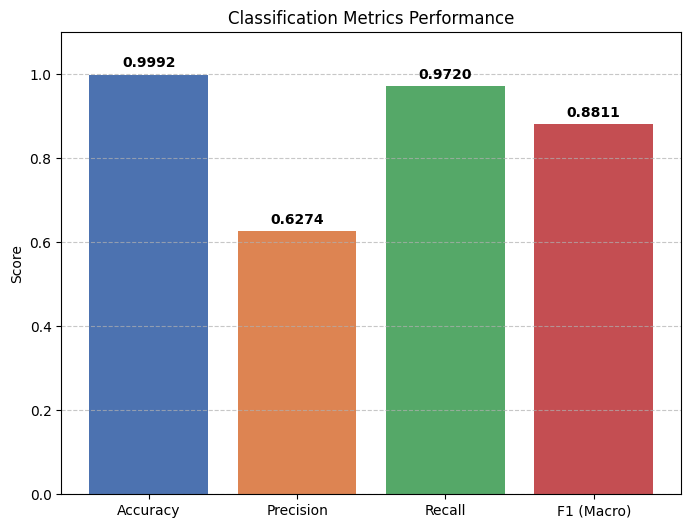

In [134]:
import matplotlib.pyplot as plt


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 (Macro)']
scores = [acc, prec, rec, f1]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, scores, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

# Add the formatted text values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', 
             ha='center', va='bottom', fontweight='bold')

# Formatting the plot
plt.ylim(0, 1.1) 
plt.title('Classification Metrics Performance')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

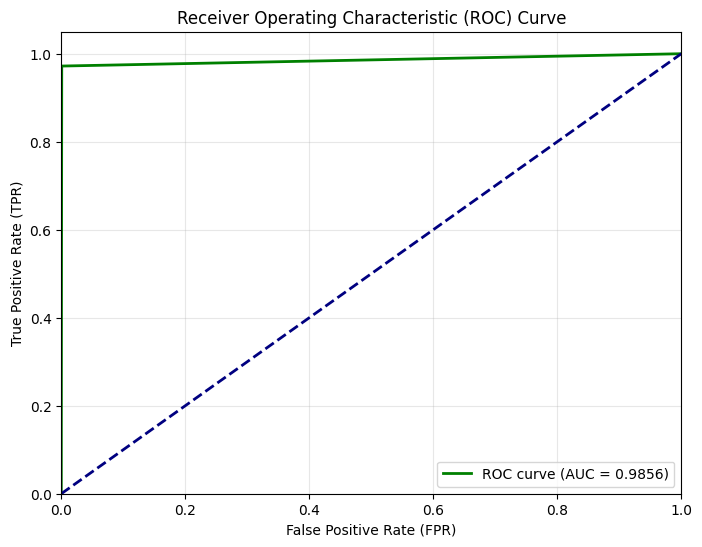

In [126]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

## Extra Stuff

Saving the model

In [ ]:
import joblib

# Save the model
joblib.dump(model, "fraud_detection_model2.pkl")

['fraud_detection_model2.pkl']

In [ ]:
import numpy as np
import os

# Create a folder to store the chunks (optional but recommended for organization)
output_dir = "test_chunks"
os.makedirs(output_dir, exist_ok=True)

# Split X_test into 10 equal chunks
X_test_chunks = np.array_split(X_test, 100)

# Save each chunk as a separate CSV file
for i, chunk in enumerate(X_test_chunks):
    # Name files from chunk_1.csv to chunk_10.csv
    file_path = os.path.join(output_dir, f"X_test_chunk_{i+1}.csv")
    
    # Save to CSV without the dataframe index
    chunk.to_csv(file_path, index=False)
    
    print(f"Saved {file_path} with {len(chunk)} rows.")

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. Define the Grid based on your requested parameters
param_grid = {
    'n_estimators': [100, 300, 500],         # How many trees to build
    'learning_rate': [0.01, 0.05, 0.1],      # Step size for each tree
    'scale_pos_weight': [50, 75, 100]        # Penalty for missing fraud
}

# 2. Initialize Base Model 
# (Locking max_depth to 6 so we only test your requested parameters)
xgb_model = XGBClassifier(
    max_depth=6,
    random_state=42
)

# 3. Configure Grid Search for F1
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',                # Optimizing strictly for F1 Score
    cv=3,
    verbose=3,
    n_jobs=-1
)

# 4. Run the Search
print("Starting Grid Search for best F1 parameters...")
grid_search.fit(X_train, y_train)

# Extract the best model
best_model = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)